In [2]:
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
mic_path = 'APD6_MIC_processed.csv'
mic_df = pd.read_csv(mic_path, dtype={'Tax_ID': str})
mic_df.head(5)

,APD_ID,Sequence,Length,Activity,MIC_Value(ug/ml),Tax_ID,Raw_Species,Target_Species,Strain
0,AP03328,TLKIIVKVVKYLV,13,"Anti-Gram+ & Gram-, Anti-MRSA, Hemolytic",0.500000,NaN,MIC (A. acidoterrestris ATCC 49025),NaN,ATCC 49025
1,AP02677,FWQKMSFA,8,Anti-Gram+ & Gram-,16.707608,NaN,MIC (A. acidoterrestris),NaN,NaN
2,AP03328,TLKIIVKVVKYLV,13,"Anti-Gram+ & Gram-, Anti-MRSA, Hemolytic",0.500000,NaN,MIC (A. acidoterrestris),NaN,NaN
3,AP00533,GVVDILKGAAKDIAGHLASKVMNKL,25,"Anti-Gram-, Antifungal",63.318178,714,MIC (A. actinomycetemcomitans),Aggregatibacter actinomycetemcomitans,NaN
4,AP00897,KRFKKFFKKLKNSVKKRAKKFFKKPKVIGVTFPF,34,"Anti-Gram+ & Gram-, Antibiofilm",16.000000,714,MIC (A. actinomycetemcomitans),Aggregatibacter actinomycetemcomitans,NaN


In [10]:
# 检查有多少没有Target species
mic_df['Target_Species'].value_counts()

Target_Species
Escherichia coli                         2870
Staphylococcus aureus                    2595
Pseudomonas aeruginosa                   1395
Candida albicans                          882
Bacillus subtilis                         731
Klebsiella pneumoniae                     703
Staphylococcus epidermidis                523
Enterococcus faecalis                     475
Acinetobacter baumannii                   450
Enterococcus faecium                      298
Salmonella typhimurium                    259
Listeria monocytogenes                    232
Bacillus cereus                           214
Salmonella enterica                       175
Candida parapsilosis                       86
Cryptococcus neoformans                    86
Vibrio parahaemolyticus                    84
Streptococcus pyogenes                     83
Fusarium oxysporum                         70
Candida tropicalis                         65
Candida glabrata                           61
Aspergillus niger  

In [6]:
mic_df["Target_Species"].isnull().sum()

3159

In [7]:
len(mic_df)

16695

In [37]:
pd.set_option('display.max_columns', None)

# 2. 显示所有行 (注意：如果数据有几万行，请谨慎使用，或改用 .head(100))
pd.set_option('display.max_rows', None)

# 3. 显示单元格内所有字符 (防止抗菌肽序列 Sequence 被截断)
pd.set_option('display.max_colwidth', None)

# 4. 确保输出宽度不换行
pd.set_option('display.width', 1000)
not_found_species = mic_df[mic_df["Target_Species"].isnull()].copy()
print(f"Number of entries without Target Species: {len(not_found_species)}")
not_found_species['Raw_Species'].value_counts()

Number of entries without Target Species: 3159


Raw_Species
MIC (M. luteus)                           241
MIC (B. pyocyaneus)                        80
MIC (E. cloacae)                           74
MIC (B. megaterium)                        71
MIC (S. cerevisiae)                        67
MIC (N. asteroides)                        55
MIC (L. lactis)                            50
MIC (P. faecalis X29)                      47
MIC (B. cinerea)                           40
MIC (B. dysenteriae)                       39
MIC (P. mirabilis)                         30
MIC (R. rhodochrous X15)                   27
MIC (A. hydrophila)                        27
MIC (S. flexneri)                          25
MIC (A. viridans)                          24
MIC (V. alginolyticus)                     23
MIC (C. glutamicum ATCC 13032)             23
MIC (M. luteus ATCC 10240)                 22
MIC (V. anguillarum)                       22
MIC (A. salmonicida)                       22
MIC (P. vulgaris)                          21
MIC (E. cloacae ATCC13

In [11]:
ADDITIONAL_SPECIES = {
    "M. luteus": "Micrococcus luteus",
    "B. pyocyaneus": "Pseudomonas aeruginosa",
    "E. cloacae": "Enterobacter cloacae",
    "B. megaterium": "Priestia megaterium",
    "S. cerevisiae": "Saccharomyces cerevisiae",
    "N. asteroides": "Nocardia asteroides",
    "L. lactis": "Lactococcus lactis",
    "B. cinerea": "Botrytis cinerea",
    "P. mirabilis": "Proteus mirabilis",
    "R. rhodochrous": "Rhodococcus rhodochrous",
    "A. hydrophila": "Aeromonas hydrophila",
    "S. flexneri": "Shigella flexneri",
    "A. viridans": "Aerococcus viridans",
    "V. alginolyticus": "Vibrio alginolyticus",
    "C. glutamicum": "Corynebacterium glutamicum",
    "V. anguillarum": "Vibrio anguillarum",
    "A. salmonicida": "Aeromonas salmonicida",
    "P. vulgaris": "Proteus vulgaris",
    "E. aerogenes": "Klebsiella aerogenes",
    "V. vulnificus": "Vibrio vulnificus",
    "S. lactis": "Sphingobacterium lactis",
    "S. choleraesuis": "Salmonella enterica",
    "S. dysenteriae": "Shigella dysenteriae",
    "A. pullulans": "Aureobasidium pullulans",
    "P. digitatum": "Penicillium digitatum",
    "P. multocida": "Pasteurella multocida",
    "V. harveyi": "Vibrio harveyi",
    "E. tarda": "Edwardsiella tarda",
    "N. haematococca": "Fusarium solani",
    "P. italicum": "Penicillium italicum",
    "S. marcescens": "Serratia marcescens",
    "L. anguillarum": "Vibrio anguillarum",
    "A. globiformis": "Arthrobacter globiformis",
    "P. expansum": "Penicillium expansum",
    "L. garvieae": "Lactococcus garvieae",
    "B. dendrobatidis": "Batrachochytrium dendrobatidis",
    "S. sonnei": "Shigella sonnei",
    "T. rubrum": "Trichophyton rubrum",
    "C. perfringens": "Clostridium perfringens"
    }
    


In [12]:
import json
# 更新 AMP_COMMON_SPECIES.json 文件
with open('../AMP_COMMON_SPECIES.json', 'r') as f:
    COMMON_SPECIES = json.load(f)

COMMON_SPECIES.update(ADDITIONAL_SPECIES)
with open('../AMP_COMMON_SPECIES.json', 'w') as f:
    json.dump(COMMON_SPECIES, f, indent=4)

In [13]:

# 更新POSSIBLE_GENE/SPECIES.json 文件
df_add = pd.DataFrame.from_dict(ADDITIONAL_SPECIES, orient='index', columns=['Full_Name'])
df_add.index.name = 'Abbreviation'
df_add["initial"] = df_add['Full_Name'].apply(lambda x: x[0])
df_add["species"] = df_add['Full_Name'].apply(lambda x: x.split()[0])  
df_add["gene"] = df_add["Full_Name"].apply(lambda x: x.split()[-1])


In [18]:
# 维护两个add的首字母的字典
species_dict = {}
gene_dict = {}
for initial, group in df_add.groupby('initial'):
    species_dict[initial] = group['species'].tolist()  
    gene_dict[initial] = group['gene'].tolist()

with open('../POSSIBLE_GENES.json', 'r') as f:
    POSSIBLE_GENES = json.load(f)
with open('../POSSIBLE_SPECIES.json', 'r') as f:
    POSSIBLE_SPECIES = json.load(f)

for initial in species_dict.keys():
    if initial in POSSIBLE_SPECIES.keys():
        POSSIBLE_SPECIES[initial].extend(species_dict[initial])
        POSSIBLE_SPECIES[initial] = list(set(POSSIBLE_SPECIES[initial]))  # 去重
    else:
        POSSIBLE_SPECIES[initial] = species_dict[initial]

    if initial in POSSIBLE_GENES.keys():
        POSSIBLE_GENES[initial].extend(gene_dict[initial])
        POSSIBLE_GENES[initial] = list(set(POSSIBLE_GENES[initial]))  # 去重
    else:       
        POSSIBLE_GENES[initial] = gene_dict[initial]

with open('../POSSIBLE_GENES.json', 'w') as f:
    json.dump(POSSIBLE_GENES, f, indent=4)
with open('../POSSIBLE_SPECIES.json', 'w') as f:    
    json.dump(POSSIBLE_SPECIES, f, indent=4)

In [19]:
from typing import Tuple
from Bio import Entrez
Entrez.email = "luyeqing21@mail.ustc.edu.cn"
# 更新TAXONOMY.json 文件
def NCBI_search(species:str, genus:str)->Tuple[str,str]:
    term = f"{species} {genus}[Scientific Name]"
    handle = Entrez.esearch(db="taxonomy", term=term)
    record = Entrez.read(handle)

    if not record["IdList"]:
        print(f"No taxonomy ID found for the given species:{species} {genus}.")
        return None, None
    tax_id = record["IdList"][0]
    summary = Entrez.efetch(db="taxonomy", id=tax_id, retmode="xml")
    data = Entrez.read(summary)

    sci_name = data[0]["ScientificName"]
    return tax_id, sci_name

addition_names = ADDITIONAL_SPECIES.values()
addition_taxonomy = {}
for full_name in addition_names:
    parts = full_name.split()
    species = parts[0]
    genus = parts[-1]
    tax_id, sci_name = NCBI_search(species, genus)
    if tax_id and sci_name:
        addition_taxonomy[full_name] = str(tax_id)

with open('../SPECIES_TAX_ID.json', 'r') as f:
    TAXONOMY = json.load(f)
TAXONOMY.update(addition_taxonomy)
with open('../SPECIES_TAX_ID.json', 'w') as f:
    json.dump(TAXONOMY, f, indent=4)


URLError: <urlopen error EOF occurred in violation of protocol (_ssl.c:1129)>

In [22]:
print(not_found_species.head(5))
print(len(not_found_species))

    APD_ID                                   Sequence  Length                                  Activity  MIC_Value(ug/ml) Tax_ID                          Raw_Species Target_Species      Strain
0  AP03328                              TLKIIVKVVKYLV      13  Anti-Gram+ & Gram-, Anti-MRSA, Hemolytic          0.500000    NaN  MIC (A. acidoterrestris ATCC 49025)            NaN  ATCC 49025
1  AP02677                                   FWQKMSFA       8                        Anti-Gram+ & Gram-         16.707608    NaN             MIC (A. acidoterrestris)            NaN         NaN
2  AP03328                              TLKIIVKVVKYLV      13  Anti-Gram+ & Gram-, Anti-MRSA, Hemolytic          0.500000    NaN             MIC (A. acidoterrestris)            NaN         NaN
5  AP02236  GYGDGCYSEDDLSVCCKKKFKVIGKCFKSVRECQNSGCKYH      41                                Antifungal          4.614267    NaN                   MIC (A. alternata)            NaN         NaN
6  AP01026              GLPVCGETCVG

In [23]:
found_species = mic_df[~mic_df["Target_Species"].isnull()]
found_species.to_csv('APD6_MIC_1.csv', index=False)

In [24]:
not_found_species.to_csv('APD6_MIC_2.csv', index=False)

In [34]:
name_df = pd.DataFrame()
print(len(not_found_species))
import re
def clean_raw_species(raw_species:str)->str:
    match = re.search(r'MIC\s*\((.*)\)', str(raw_species))
    full_content = match.group(1).strip() # 例如 "A. baumanii CI 2675"
    cleaned_species = " ".join(full_content.split()[:2])
    return cleaned_species
name_df = not_found_species["Raw_Species"].drop_duplicates().to_frame(name="raw")
name_df["cleaned"] = name_df["raw"].apply(clean_raw_species)
name_df.drop_duplicates(subset=["cleaned"], inplace=True)
print(len(name_df))

3159
512


In [38]:
def split_strain_species(raw_species:str)->Tuple[str, str]:
    parts = raw_species.split()
    if len(parts) > 2:
        species_part = " ".join(parts[:2]) # "A. baumanii"
        strain_part = " ".join(parts[2:])   # "CI 2675"
    else:
        species_part = raw_species
        strain_part = ""

    return species_part, strain_part


not_found_species["Raw_Species"] = not_found_species["Raw_Species"].apply(lambda x: re.search(r'MIC\s*\((.*)\)', str(x)).group(1).strip())
not_found_species[["Raw_Species", "Strain"]] = not_found_species["Raw_Species"].apply(lambda x: pd.Series(split_strain_species(x)))
print(not_found_species.head(3))
# 获取唯一物种列表
unique_species = not_found_species["Raw_Species"].drop_duplicates().tolist()
print(len(unique_species))

    APD_ID       Sequence  Length                                  Activity  MIC_Value(ug/ml) Tax_ID         Raw_Species Target_Species      Strain
0  AP03328  TLKIIVKVVKYLV      13  Anti-Gram+ & Gram-, Anti-MRSA, Hemolytic          0.500000    NaN  A. acidoterrestris            NaN  ATCC 49025
1  AP02677       FWQKMSFA       8                        Anti-Gram+ & Gram-         16.707608    NaN  A. acidoterrestris            NaN            
2  AP03328  TLKIIVKVVKYLV      13  Anti-Gram+ & Gram-, Anti-MRSA, Hemolytic          0.500000    NaN  A. acidoterrestris            NaN            
512


In [39]:
# 合并MIC两张表，Tax_ID none的去掉
# 去重
df1 = pd.read_csv('APD6_MIC_1.csv', dtype={'Tax_ID': str})
df2 = pd.read_csv('processed_APD6_MIC_2.csv', dtype={'Tax_ID': str})
print(f"df1:{len(df1)}")
print(f"df2:{len(df2)}")
combined_df = pd.concat([df1, df2], ignore_index=True)
combined_df.dropna(subset=['Tax_ID'], inplace=True)
combined_df.drop_duplicates(inplace=True)
print(f"combined_df:{len(combined_df)}")


df1:13536
df2:3159
combined_df:15157


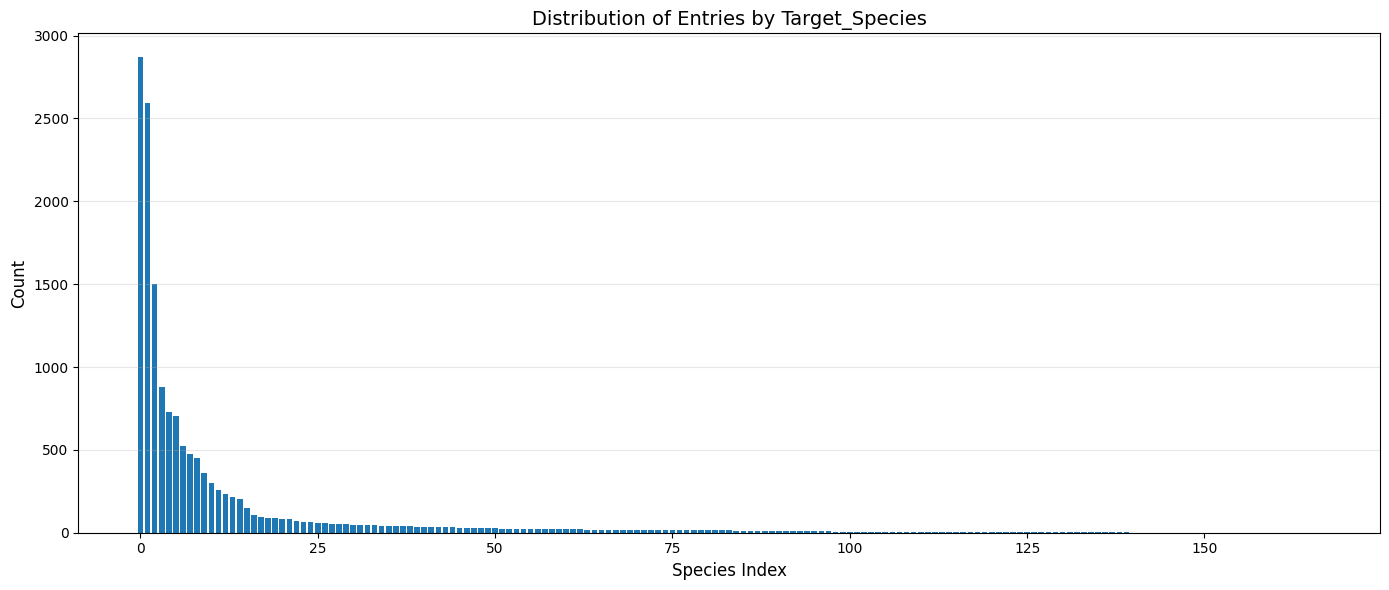

Total unique species: 167
Top 10 species:
Target_Species
Escherichia coli              2870
Staphylococcus aureus         2595
Pseudomonas aeruginosa        1501
Candida albicans               882
Bacillus subtilis              731
Klebsiella pneumoniae          703
Staphylococcus epidermidis     523
Enterococcus faecalis          475
Acinetobacter baumannii        450
Micrococcus luteus             359
Name: count, dtype: int64


In [40]:
# 按照Target_Species的数量的直方图
species_counts = combined_df['Target_Species'].value_counts()
plt.figure(figsize=(14, 6))
plt.bar(range(len(species_counts)), species_counts.values)
plt.xlabel('Species Index', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Entries by Target_Species', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total unique species: {len(species_counts)}")
print(f"Top 10 species:")
print(species_counts.head(10))

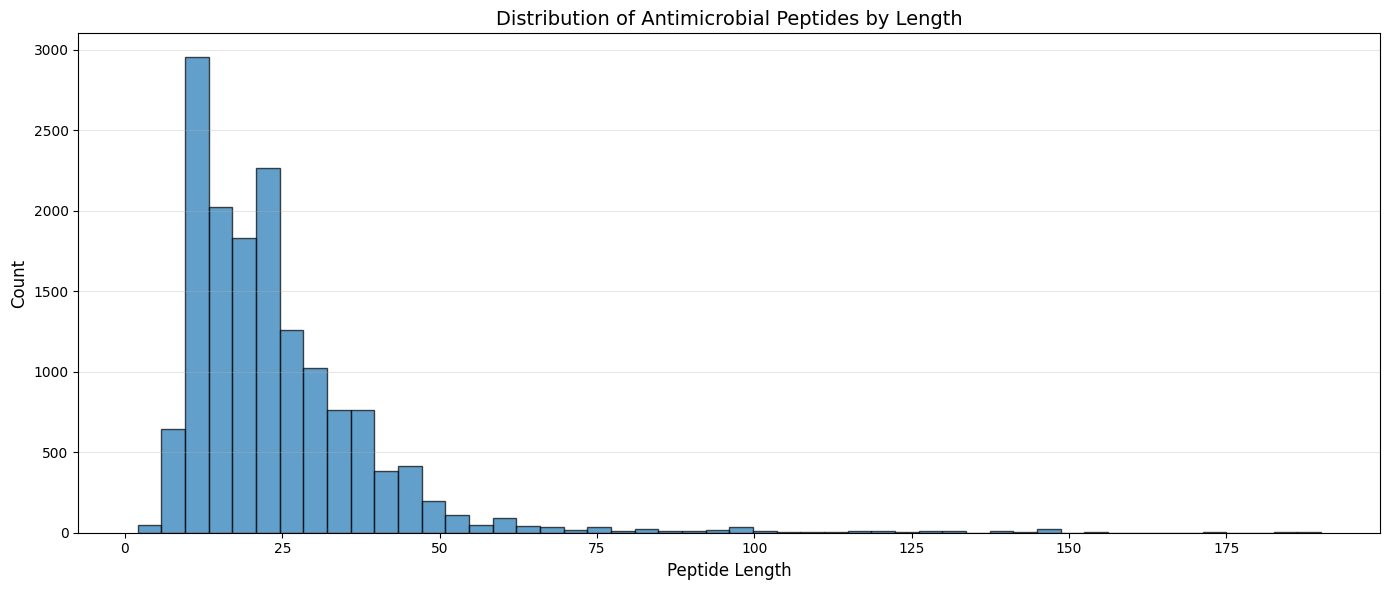

Length Statistics:
count    15157.000000
mean        24.316619
std         16.113753
min          2.000000
25%         14.000000
50%         21.000000
75%         30.000000
max        190.000000
Name: Length, dtype: float64


In [41]:
# 按照长度Length的直方图
plt.figure(figsize=(14, 6))
plt.hist(combined_df['Length'].dropna(), bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Peptide Length', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Antimicrobial Peptides by Length', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Length Statistics:")
print(combined_df['Length'].describe())

In [42]:
combined_df.to_csv('APD6_MIC_final.csv', index=False)